# 📊 Retail Sales Analysis using Python

## Business Problem

A retail company wants to analyze its historical sales data to understand customer behavior, sales trends, profitability, and business performance.

---

## Objectives

- Analyze sales performance
- Identify profitable categories
- Identify loss-making products
- Understand customer segments
- Analyze regional performance
- Generate business recommendations

## 📦 Import Libraries

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
plt.style.use("ggplot")

## 📂 Load Dataset

In [132]:
df = pd.read_csv(r"C:\Users\Parveen Kumar\OneDrive\Desktop\Retail Sales Analytics\Dataset\SampleSuperstore.csv")

## 🔍 Data Inspection

In [133]:
print("=" * 65,"Dataset Overview","=" * 65)
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nStatistical Summary:")
print(df.describe())
print("\nUnique Values per Column:")
print(df.nunique())

================================================================= Dataset Overview =================================================================
Shape: (9994, 13)

Columns:
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

First 5 Rows:
        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Clas

## 🧹 Data Cleaning

In [134]:
df.isnull().sum()
duplicate_count = df.duplicated().sum()
print(f"Duplicate Records: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records removed successfully.")
else:
    print("No duplicate records found.")
print("Updated Dataset Shape:", df.shape)

Duplicate Records: 17
Duplicate records removed successfully.
Updated Dataset Shape: (9977, 13)


## 📌 Observation

- The dataset contains **9,977 records** and **13 columns**.
- No missing values were found.
- Duplicate records were checked and removed if present.
- The dataset is ready for exploratory data analysis.

## 📊 Category Analysis

### Business Question
**Q1** :- How are orders distributed across categories?

In [135]:
category_counts = df["Category"].value_counts()
print(category_counts)

Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64


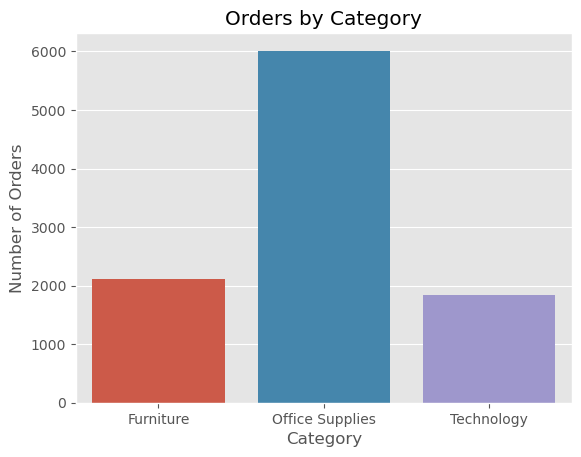

In [136]:
sns.countplot(data=df,x="Category",hue="Category",legend=False)
plt.title("Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.show()

### 📌 Observation
Office Supplies received the highest number of customer orders, followed by Furniture and Technology, indicating strong customer demand for office-related products.
### 💼 Business Recommendation
Maintain sufficient inventory for Office Supplies to prevent stock shortages. For lower-performing categories, implement targeted marketing campaigns, promotional discounts, or product bundling strategies to improve sales performance.

**Q2** :- Which region has the highest number of orders?

<Axes: xlabel='Region', ylabel='count'>

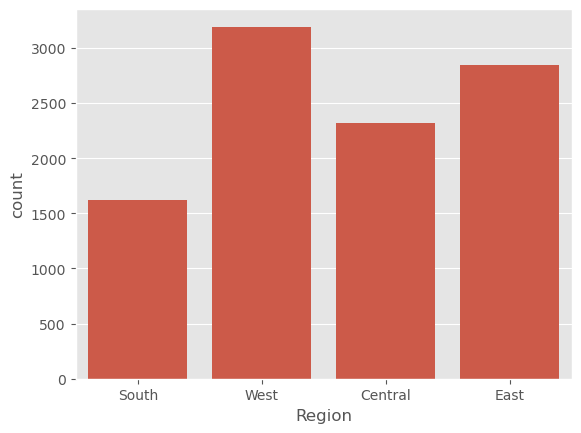

In [137]:
region_counts = df["Region"].value_counts()
sns.countplot(data=df, x="Region")

### 📌 Observation
The West and East regions recorded the highest number of customer orders, while the South and Central regions received comparatively fewer orders.
### 💼 Business Recommendation
Maintain strong inventory and customer service in the West and East regions while implementing targeted marketing campaigns and promotional offers to increase customer orders in the South and Central regions.

**Q3** :- Which customer segment places the most orders?

<Axes: xlabel='Segment', ylabel='count'>

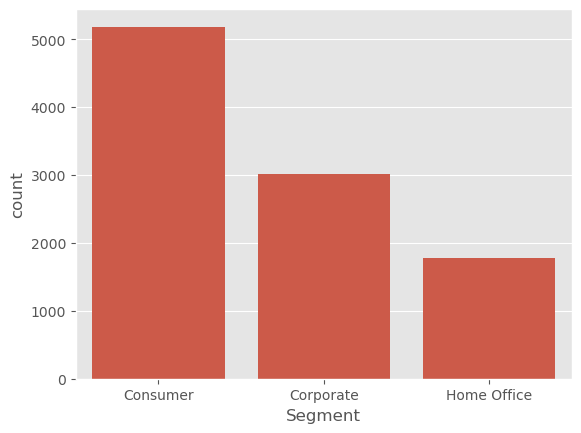

In [139]:
df["Segment"].value_counts()
sns.countplot(data=df, x="Segment")

### 📌 Observation
The Consumer segment placed the highest number of orders, followed by the Corporate and Home Office segments, indicating that individual consumers are the primary customer base.
### 💼 Business Recommendation
Maintain sufficient inventory to meet the high demand from the Consumer segment. To increase sales in the Corporate and Home Office segments, implement targeted marketing campaigns, promotional offers, and customer-specific discounts based on their purchasing behavior.

**Q4** :- Which shipping mode is used the most?

<Axes: xlabel='Ship Mode', ylabel='count'>

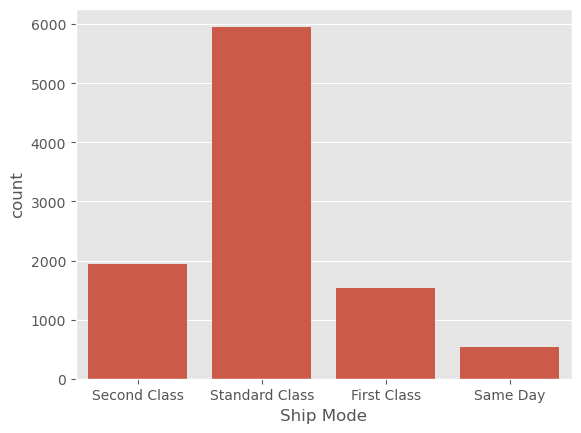

In [140]:
df["Ship Mode"].value_counts
sns.countplot(data=df, x="Ship Mode")

### 📌 Observation
Standard Class was the most frequently used shipping mode, indicating that customers generally prefer economical shipping options over faster delivery methods.
### 💼 Business Recommendation
Continue optimizing the Standard Class shipping process to maintain customer satisfaction. Promote faster shipping options through discounts or loyalty benefits for customers who require quicker deliveries.

**Q5** :- Which category generated the highest sales?

<Axes: xlabel='Category'>

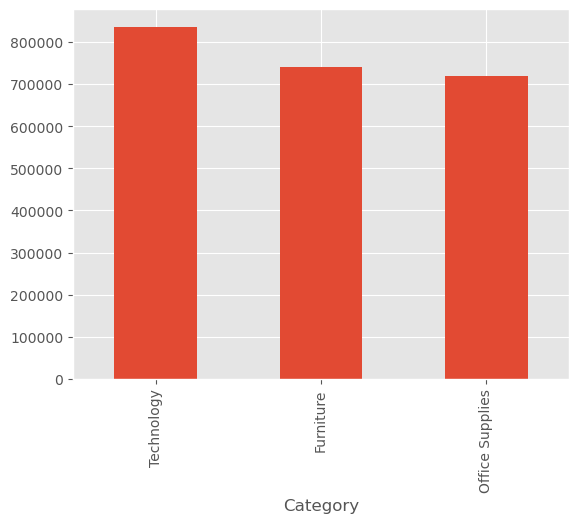

In [141]:
sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sales.plot(kind="bar")

### 📌 Observation
The Technology category generated the highest total sales, followed by Furniture and Office Supplies, indicating strong customer demand for technology products.
### 💼 Business Recommendation
Increase inventory and marketing efforts for Technology products while identifying opportunities to improve the sales performance of Furniture and Office Supplies through promotional campaigns and bundled offers.

**Q6** :- Which category generated the highest profit?

<Axes: xlabel='Category'>

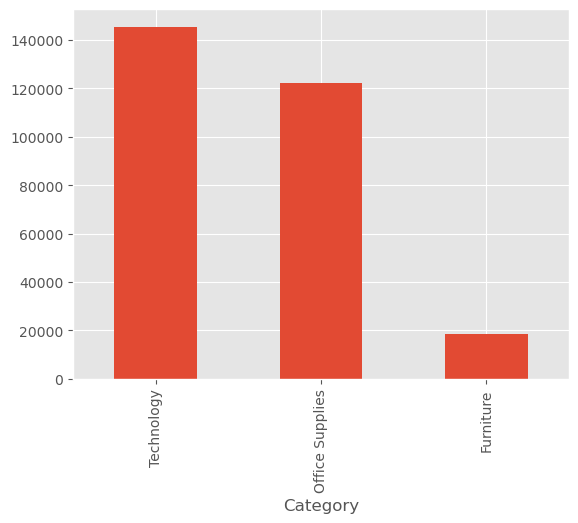

In [142]:
profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
profit.plot(kind="bar")

### 📌 Observation
The Technology category generated the highest overall profit, demonstrating its strong contribution to the company's profitability.
### 💼 Business Recommendation
Continue investing in the Technology category by expanding product offerings and maintaining competitive pricing. Review pricing strategies and operational costs for lower-profit categories to improve overall profitability.

**Q7** :- Which sub-category generated the highest loss?

<Axes: ylabel='Sub-Category'>

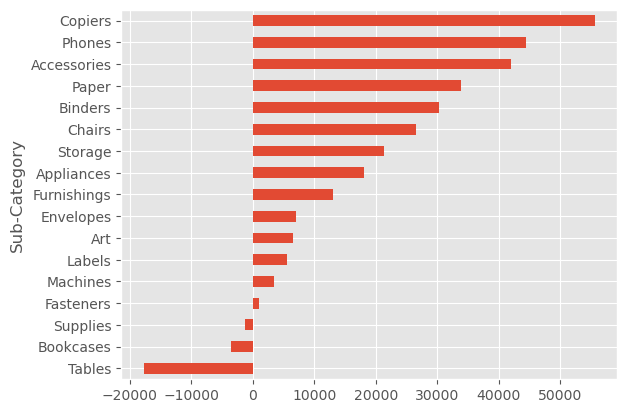

In [143]:
loss = (df.groupby("Sub-Category")["Profit"].sum().sort_values())
loss.plot(kind="barh")

### 📌 Observation
The Tables sub-category recorded the highest overall loss, indicating that it negatively impacts the company's profitability despite generating sales.
### 💼 Business Recommendation

Review the pricing strategy, supplier costs, and discount policies for the Tables sub-category. Reduce excessive discounts and optimize procurement costs to minimize future losses.

**Q8** :- Which states generated the highest sales?

<Axes: xlabel='State'>

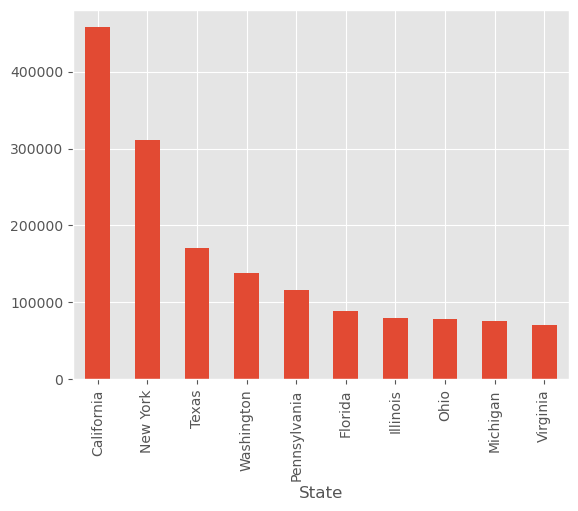

In [144]:
state_sales = (df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10))
state_sales.plot(kind="bar")

### 📌 Observation
California generated the highest total sales among all states, indicating a strong customer base and market presence in that region.
### 💼 Business Recommendation
Maintain inventory levels and marketing investments in California while identifying growth opportunities in lower-performing states through regional promotions and customer engagement initiatives.

**Q9** :- Discount vs Profit

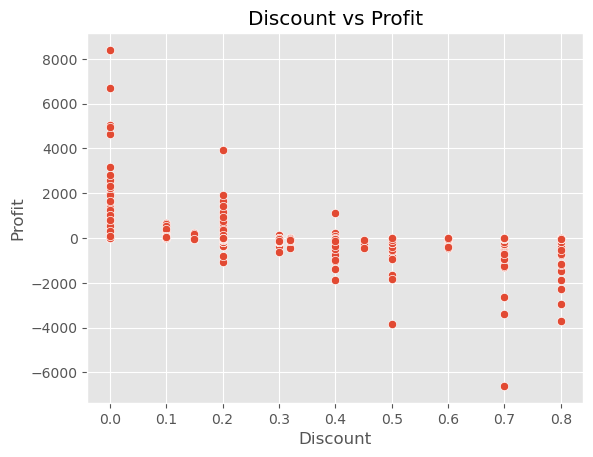

In [145]:
sns.scatterplot(data=df,x="Discount",y="Profit")
plt.title("Discount vs Profit")
plt.show()

### 📌 Observation
Higher discounts generally resulted in lower profits, indicating that excessive discounting negatively affects overall profitability.
### 💼 Business Recommendation
Implement controlled discount strategies by offering discounts selectively on high-margin products. Regularly evaluate discount policies to ensure they drive sales without significantly reducing profit margins.

**Q10** :- Correlation Heatmap

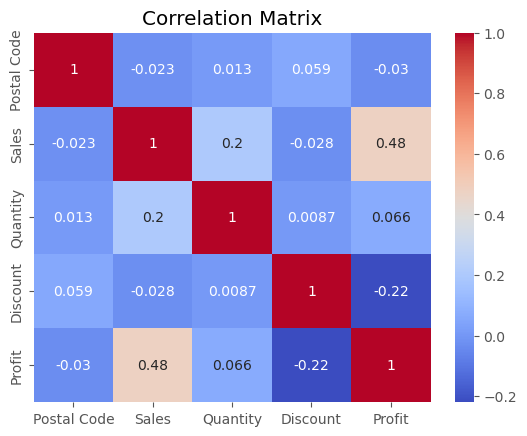

In [146]:
sns.heatmap(df.select_dtypes(include="number").corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### 📌 Observation
The correlation analysis indicates that Sales, Quantity, Discount, and Profit have relatively weak linear relationships, suggesting that multiple factors influence business performance rather than a single variable.
### 💼 Business Recommendation
Avoid making business decisions based on a single metric. Combine sales, profit, discount, customer segments, and regional performance when developing pricing strategies, inventory planning, and marketing campaigns.

# 📌 Conclusion

This project helped me analyze the Superstore sales dataset using Python. By performing data cleaning, exploratory data analysis, and data visualization, I identified important sales and profit trends across different categories, regions, customer segments, and shipping modes.

### Key Findings

- Office Supplies received the highest number of customer orders.
- The West and East regions recorded more orders than the South and Central regions.
- The Consumer segment placed the highest number of orders.
- Standard Class was the most preferred shipping mode.
- Technology generated the highest sales and profit.
- Higher discounts were associated with lower profits in many cases.
- The Tables sub-category contributed the highest losses.

### Business Recommendations

- Maintain sufficient inventory for high-demand products.
- Improve sales in lower-performing regions through promotions and marketing.
- Review discount strategies to improve profitability.
- Focus on reducing losses in underperforming product categories.

This project strengthened my understanding of Python, Pandas, Matplotlib, Seaborn, and exploratory data analysis while improving my ability to extract business insights from data.